## Lession 3 - MLflow: Advanced Experiment Tracking (MLflow 3.14)

### <b> Learning Objectives </b>
By the end of this lesson, you will be able to:
* Understand the purpose of autologging and when to use it.
* Log datasets for reproducibility.
* Log model signatures and input examples.
* Log artifacts such as plots and reports.
* Organize experiments using tags.
* Record additional metadata for better experiment management.

#### <b> Section 1 </b> : Automatic Logging (Autologging)

<b> What is Autologging? </b>  
In Lessons 1 and 2 (MLflow basics), we manually logged everything using mlflow.log_params, mlflow.log_metrics and mlflow.sklearn.log_model.  

While this gives full control but can become repetitive.   

MLflow provides Autologging, which automatically captures many of these details.

What Does <b> mlflow.autolog() </b> Capture?  

For scikit-learn models, autologging can automatically log:

* Parameters
* Metrics
* Model
* Model Signature
* Input Example
* Training Duration
* sklearn Version
* Python Environment


#### <b> Logging Strategy </b>
<table>
<tr>
<td> 
<b> Use Autologging </b></br>
* Rapid experimentation  </br>
* Jupyter notebooks </br>
* Learning MLflow </br>
* Baseline models </br>
</td> 

<td> 
<b> Prefer Manual Logging </b></br>
* Production pipelines </br>
* Custom metrics </br>
* Business KPIs </br>
* Domain-specific artifacts </br>
</td>
</tr>
</table>

<b> Many production teams use both: </b>
* Autologging for standard metadata.
* Manual logging for custom metrics and artifacts.

#### Enable Autologging

In [ ]:
import mlflow

# Enable automatic logging for supported libraries
# Just one line, no configuration required.
mlflow.autolog()

#### Simplify Your Training Code

In [ ]:
import mlflow
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

mlflow.autolog()
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("RandomForest Autolog Experiment")

# Load the iris dataset
iris = load_iris()

# Prepare the data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["target"] = iris.target

# Split the data into training and testing sets
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

with mlflow.start_run():
    # Create model for each combination of hyperparameters
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    )
    # Train the model
    model.fit(X_train, y_train)

    # Evaluate the model
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Log accuracy as a metric, Custom metrics can still be logged manually
    mlflow.log_metric("accuracy", accuracy)

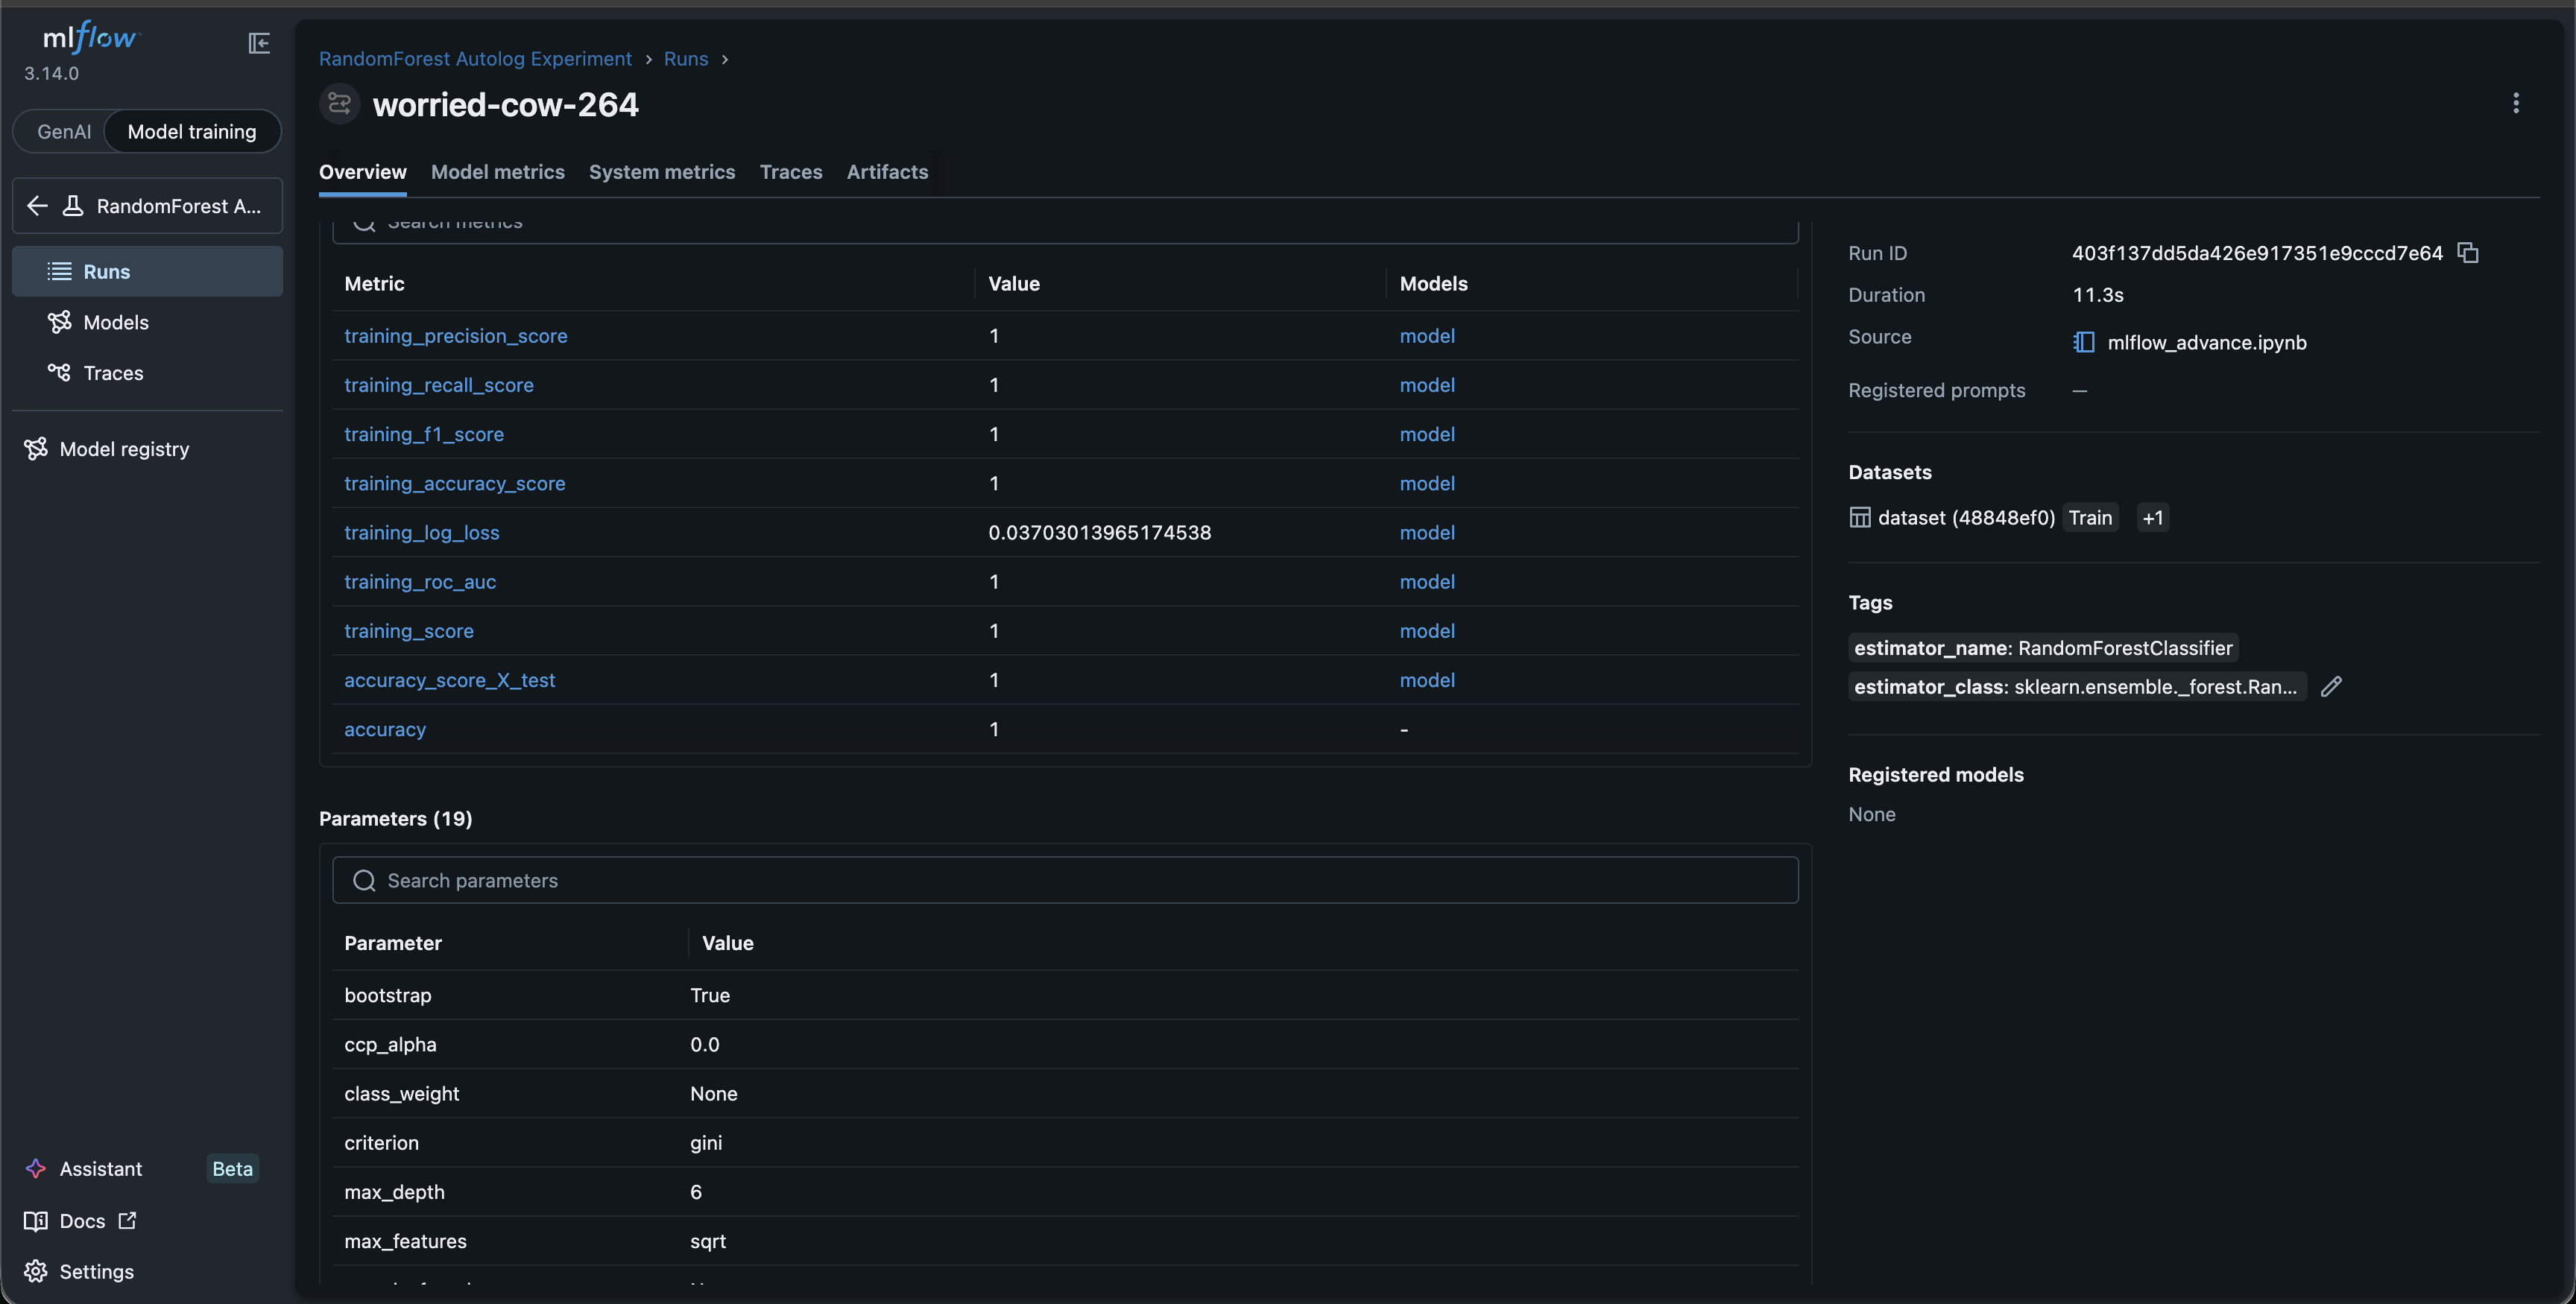

## Lesson 3.5 - MLflow Tracking Server

The MLflow Tracking Server is the central service that records, stores, and manages all machine learning experiments. Instead of saving experiment data locally in the notebook or the mlruns directory, the tracking server provides a centralized endpoint where multiple users, notebooks, and applications can log and retrieve experiment information.

In [ ]:
# Start a MLflow Tracking Server, instead of `mlflow ui`
mlflow server \
    --host 127.0.0.1 \
    --port 5000 \
    --backend-store-uri sqlite:///mlflow.db \
    --artifacts-destination ./artifacts

This command starts:  
  ✅ The MLflow Tracking Server (REST API)  
  ✅ The MLflow Web UI  
  ✅ Backend Store (e.g., SQLite, PostgreSQL)  
  ✅ Artifact Store  
  ✅ Model Registry  

## Lesson 4 – Model Registry & Model Lifecycle Management (MLflow 3.14)

### Learning Objectives
By the end of this lesson, you will be able to:
* Understand the purpose of the Model Registry.
* Register logged models.
* Create and manage multiple model versions.
* Understand Model IDs, Model URIs, and Registered Models.
* Load models by different URI types.
* Understand model aliases and the modern MLflow 3.x workflow.
* Compare the MLflow 2.x and 3.x approaches to model management.

### Model Registry
The MLflow Model Registry is a centralized repository for managing the lifecycle of machine learning models. While Experiment Tracking records every training run, the Model Registry organizes the selected models, maintains their versions, and prepares them for deployment.

<b>Key Benefits:</b>  
* Centralized Management – Store and organize trained models in one place.
* Versioning – Maintain multiple versions with complete history.
* Traceability – Link each model to its originating experiment and run.
* Deployment Ready – Simplify model promotion using versions and aliases.

Experiment Tracking finds the best model; Model Registry manages its lifecycle.

##### <b>Logged Model:</b>
Every time `mlflow.sklearn.log_model()` is executed, MLflow creates a Logged Model which belongs to a specific Run.

##### <b>Registered Model:</b>
A Registered Model is a named collection of model versions. It does not represent a single model. Instead, it groups all versions together.
* <b>Model Versions:</b> Each time you register a newer model under the same registered model name, MLflow creates a new version.
* <b>Model ID:</b> Every logged model receives a globally unique identifier(e.g. m-cab12ef98d3e4d5). This uniquely identifies one logged model.
* <b>Model URI:</b> A Model URI tells MLflow where to locate a model. (e.g. models:/iris-random-forest/1)


##### <b>Step 1</b> – Get the Best Run
We'll reuse what we learned in Lesson 2.

In [ ]:
import mlflow

# Get the experiment
experiment = mlflow.get_experiment_by_name("RandomForest Iris Classification Experiment")

# Search all runs
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Select the run with the highest accuracy
best_run = runs.sort_values(
    by="metrics.accuracy",
    ascending=False
).iloc[0]

best_run_id = best_run["run_id"]

print(best_run_id)

##### <b>Step 2</b> – Build the Model URI

In [ ]:
model_name = "model"
model_uri = f"runs:/{best_run_id}/{model_name}"
print(model_uri)

##### <b>Step 3</b> – Register the Model

In [ ]:
import mlflow

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="iris-random-forest"
)

Navigate to `Model Registry` on the left panel.  

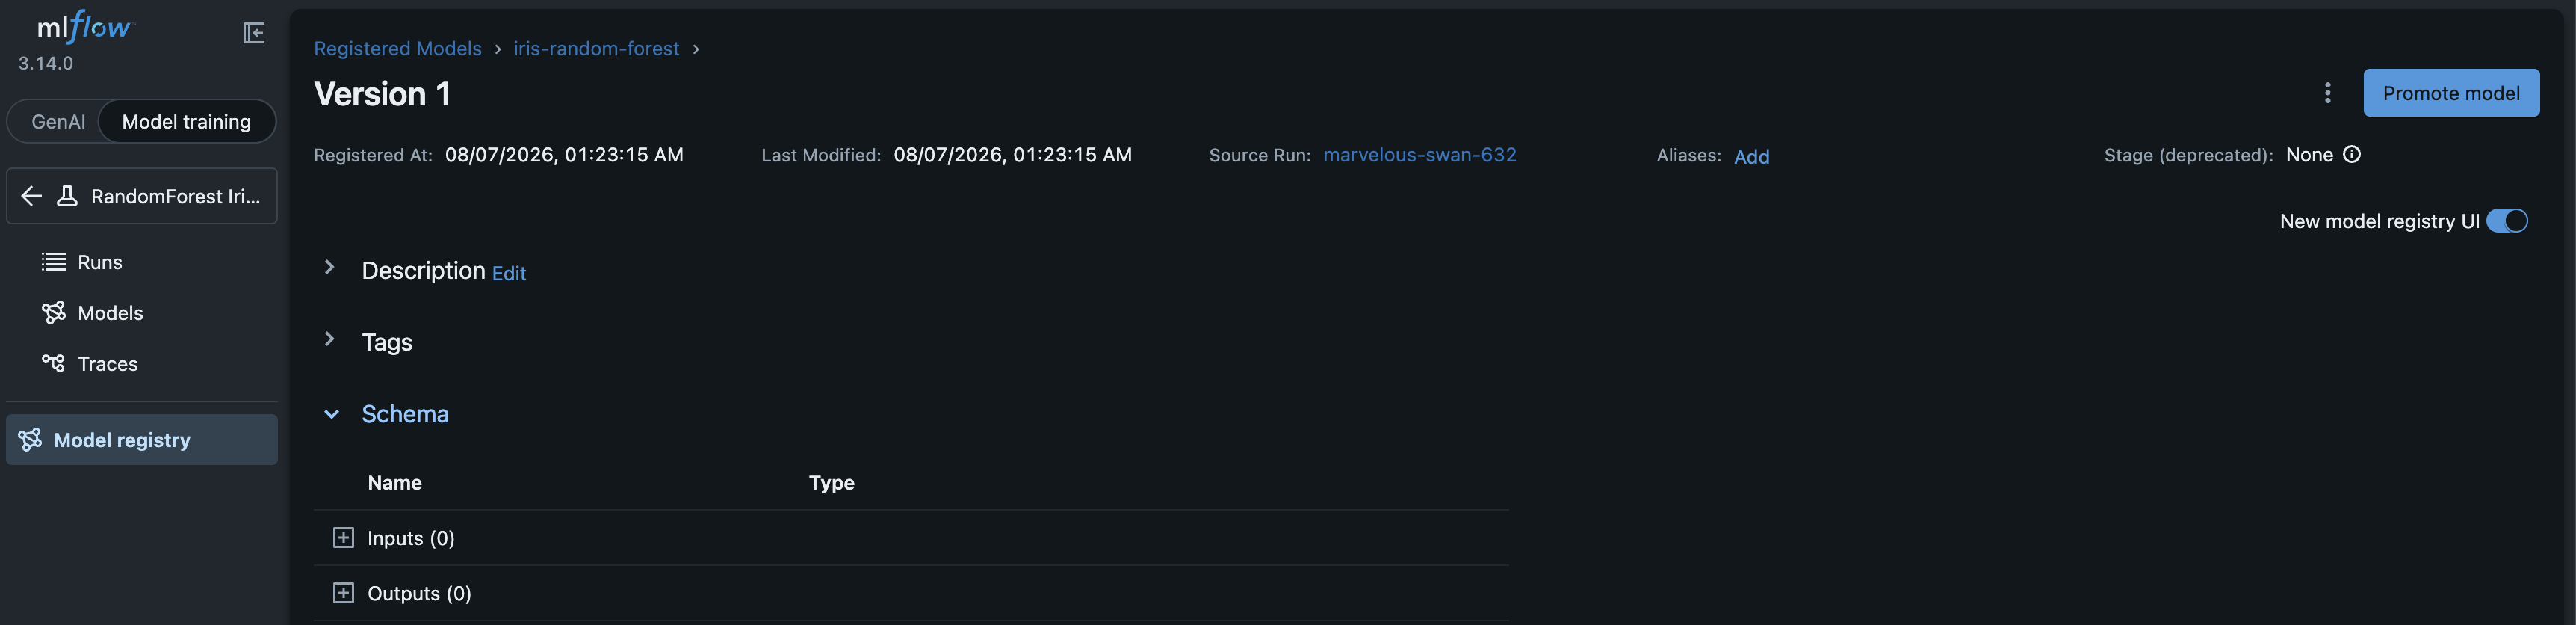

#### <b>Step 4</b> - Verify Programmatically

In [ ]:
from mlflow import MlflowClient

client = MlflowClient()

client.search_registered_models()

# To Inspect Version:
client.search_model_versions(
    filter_string="name='iris-random-forest'"
)

## Lesson 5 – Model Evaluation

### Learning Objectives
By the end of this lesson, you will be able to:
* Evaluate a trained model using multiple performance metrics.
* Generate and interpret common evaluation reports.
* Log evaluation artifacts to MLflow.
* Compare model performance across multiple runs.
* Understand how evaluation supports model selection.

##### The typical ML Workflow is: 

In [ ]:

Train Model
      │
      ▼
Evaluate Model
      │
      ▼
Compare Models
      │
      ▼
Register Best Model
      │
      ▼
Deploy

Even though we introduced the Model Registry in Lesson 4 to explain the concept, in real-world projects, comprehensive evaluation is what determines whether a model should be promoted or remain as an experimental version.

### <b>Section 1:</b> Manual Evaluation

##### <b>Step 1:</b> Imports

In [ ]:
import os
import tempfile

import mlflow
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

##### <b>Step 2:</b> Load the Best Model from MLflow

In [ ]:
# Create a new experiemnt

import mlflow
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

mlflow.autolog()
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Iris Random Forest Evaluation")

# Load the iris dataset
iris = load_iris()

# Prepare the data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["target"] = iris.target

# Split the data into training and testing sets
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

with mlflow.start_run():
    # Create model for each combination of hyperparameters
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    )
    # Train the model
    model.fit(X_train, y_train)

    # Evaluate the model
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Log accuracy as a metric, Custom metrics can still be logged manually
    mlflow.log_metric("accuracy", accuracy)

In [ ]:
# Get the experiment
experiment = mlflow.get_experiment_by_name("Iris Random Forest Evaluation")

# Search all runs
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Select the best run based on accuracy
best_run = runs.sort_values(
    by="metrics.accuracy",
    ascending=False
).iloc[0]

best_run_id = best_run["run_id"]

# Build the model URI
model_uri = f"runs:/{best_run_id}/model"

print("Best Run ID :", best_run_id)
print("Model URI   :", model_uri)

# Load the model
best_model = mlflow.sklearn.load_model(model_uri)

##### <b>Step 3:</b> Run Predictions

In [ ]:
# Predict using the best model
y_pred = best_model.predict(X_test)

print(y_pred[:10])

##### <b>Step 4:</b> Calculate Evaluation Metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

##### <b>Step 5:</b> Generate Classification Report

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
)

print(report)

##### <b>Step 6:</b> Create a Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

##### <b>Step 7:</b> Log Evaluation Metrics & Artifacts
Now we'll create a new evaluation run.

In [ ]:
with mlflow.start_run(run_name="Model Evaluation"):

    # Log evaluation metrics
    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    # Save confusion matrix
    temp_dir = tempfile.mkdtemp()

    figure_path = os.path.join(
        temp_dir,
        "confusion_matrix.png"
    )

    plt.figure()
    disp.plot()
    plt.savefig(figure_path, bbox_inches="tight")
    plt.close()

    # Log artifact
    mlflow.log_artifact(figure_path)

print("Evaluation artifacts logged successfully.")

After running this cell, the new run will contain:

<b><u>Metrics</u></b>
* Accuracy
* Precision
* Recall
* F1 Score

<b><u>Artifacts</u></b>
* confusion_matrix.png

Till now, we have evaluated the model manually by generating accuracy, precission etc. Instead of manually calculating metrics and creating artifacts, MLflow can evaluate a model and log a comprehensive evaluation report for you.  
  
Now we'll cover one of the most powerful features introduced in recent MLflow versions: <b>mlflow.evaluate()</b>.

### <b>Section 2:</b> Model Evaluation with mlflow.evaluate()

##### <b>What is `mlflow.evaluate()`</b>
`mlflow.evaluate()` is a high-level API that evaluates a trained model on a dataset and automatically computes metrics, generates artifacts, and logs the results to MLflow.

<b>Benefits:</b>
* Automatic metric calculation
* Automatic artifact generation
* Standardized evaluation across projects
* Simplified model comparison

##### <b>Step 8:</b> Prepare the Evaluation Dataset
`mlflow.evaluate()` expects the features and target in a single DataFrame.

In [ ]:
# Create evaluation DataFrame
eval_data = X_test.copy()

# Add the target column
eval_data["target"] = y_test

# Verify the dataset:
eval_data.head()

##### <b>Step 9:</b> Evaluate the Model

In [ ]:
with mlflow.start_run(run_name="MLflow Evaluate"):

    evaluation_result = mlflow.evaluate(
        model=model_uri, # URI of the logged model
        data=eval_data, # Evaluation dataset
        targets="target", # Name of the target column
        model_type="classifier" # Type of model being evaluated
    )

##### <b>Step 10:</b> View the Evaluation Metrics

In [ ]:
evaluation_result.metrics

In [ ]:
# Access Individual metrics
print(evaluation_result.metrics["accuracy_score"])

##### <b>Step 11:</b> View the Generated Artifacts

In [ ]:
evaluation_result.artifacts

# Typical output may include entries such as:
    # confusion_matrix
    # per_class_metrics
    # classification_report

#### <b> Best Practice </b>
In production, it's common to combine both approaches:

In [ ]:
with mlflow.start_run():

    evaluation_result = mlflow.evaluate(
        model=model_uri,
        data=eval_data,
        targets="target",
        model_type="classifier"
    )

    # Log business-specific metrics
    mlflow.log_metric("cost_per_prediction", 0.002)

    # Log custom artifacts
    mlflow.log_artifact("feature_importance.png")

#### <b>Lesson 5 Summary</b>
<b>By the end of this lesson, you've learned how to:</b>
* Evaluate a model manually using scikit-learn metrics.
* Create a confusion matrix and classification report.
* Log evaluation metrics and artifacts to MLflow.
* Use mlflow.evaluate() to automate model evaluation.
* Compare manual and automated evaluation workflows.  

This completes the evaluation phase of the ML lifecycle. 

The next lesson will focus on Model Serving & Inference, where you'll learn how to deploy and consume the models you've trained and evaluated.